In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import matplotlib.pyplot as plt

seed = 52

CWD = os.getcwd()
DATA_PATH = os.path.join(CWD, '10xMouse_loom_preprocessed.h5ad')
SAVING_FOLDER = os.path.join(CWD, "scRNA_adata")

if not os.path.exists(SAVING_FOLDER):
    os.makedirs(SAVING_FOLDER)

adata = sc.read_h5ad(DATA_PATH)

c:\Users\aless\Desktop\scVEMO\lib\site-packages\setuptools_scm\_integration\setuptools.py:30: RuntimeWarning: 
ERROR: setuptools==49.2.1 is used in combination with setuptools_scm>=8.x

Your build configuration is incomplete and previously worked by accident!
setuptools_scm requires setuptools>=61

Suggested workaround if applicable:
 - migrating from the deprecated setup_requires mechanism to pep517/518
   and using a pyproject.toml to declare build dependencies
   which are reliably pre-installed before running the build tools

  warnings.warn(


In [2]:
k = 30
pc = 15
res = 1.0

computing neighbors
    finished (0:00:07) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


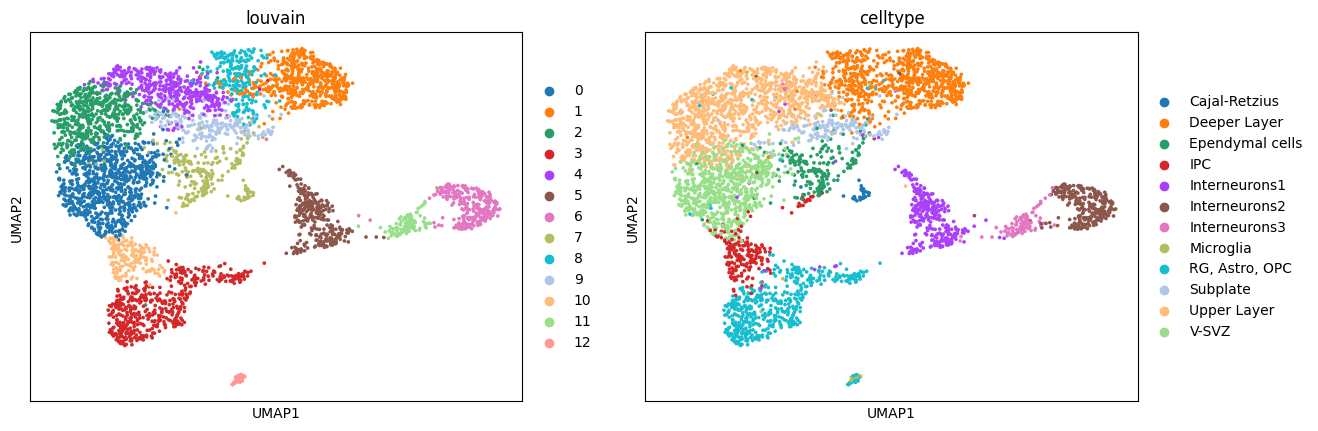

In [3]:
scv.pp.moments(adata, n_neighbors=k, n_pcs=pc)
sc.pp.neighbors(adata, n_neighbors=k, n_pcs=pc, random_state = seed)
sc.tl.louvain(adata, resolution=res, random_state=seed)
sc.tl.umap(adata, random_state=seed)
sc.pl.umap(adata, color=['louvain', 'celltype'])

In [4]:
# Recovers full splicing kinetics 
scv.tl.recover_dynamics(adata, n_jobs=-1)

recovering dynamics (using 8/8 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:04:09) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)


In [5]:
scv.tl.velocity(adata, mode='dynamical')
scv.tl.velocity_graph(adata, n_jobs=-1)

computing velocities
    finished (0:00:05) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 8/8 cores)
    finished (0:00:07) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)
saving figure to file ./figures/scvelo_dynamicalModel_30K15PC1.0resolution.png


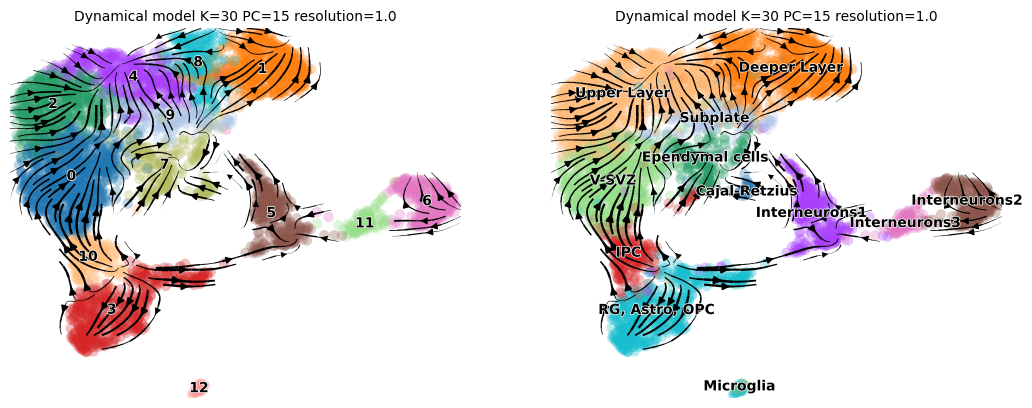

In [6]:
title = f"Dynamical model K={k} PC={pc} resolution={res}"
path= f"dynamicalModel_{k}K{pc}PC{res}resolution.png"
scv.pl.velocity_embedding_stream(adata, basis='umap', color=['louvain', 'celltype'], title=title, save= path)

computing terminal states
    identified 1 region of root cells and 1 region of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)
computing latent time using root_cells as prior
    finished (0:00:02) --> added 
    'latent_time', shared time (adata.obs)
saving figure to file ./figures/scvelo_latentTime_30K15PC1.0resolution.png


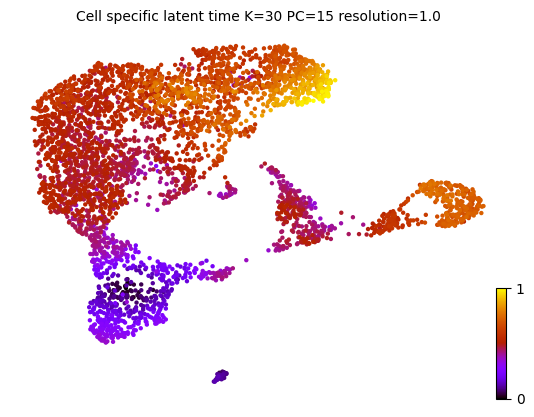

In [7]:
# Compute latent time (cell's internal clock)
title = f"Cell specific latent time K={k} PC={pc} resolution={res}"
path= f"latentTime_{k}K{pc}PC{res}resolution.png"
scv.tl.latent_time(adata)
scv.pl.scatter(adata, color='latent_time', color_map='gnuplot', size=40, save=path, title=title)

In [8]:
# Saving file
path = os.path.join(SAVING_FOLDER, f"scVeloDynamical_{k}K{pc}PC{res}res.h5ad")
adata.write_h5ad(path)